## Algorithm — 2-Group Diffusion in a Planar Slab Reactor (Bare + Reflected)

### Goal
Solve the 1D two-group neutron diffusion $k$-eigenvalue problem in slab geometry with finite differences (mesh size $\Delta x=0.1\ \mathrm{cm}$). Compute $k_{\mathrm{eff}}$, net currents at the requested interfaces, and produce the requested flux and error plots for:
- **Bare core** (no reflector), modeled on the RHS with symmetry at the core center.
- **Reflected core** (core + reflector), with material properties changing by region.

---

### 1) Governing equations (two energy groups)
Unknowns are the group fluxes $\phi_1(x)$ (fast) and $\phi_2(x)$ (thermal). In each region (core/reflector) they satisfy, in diffusion form,
$$
-\frac{d}{dx}\!\left(D_g\frac{d\phi_g}{dx}\right)+\Sigma_{r,g}\phi_g = S_g(\phi_1,\phi_2;k),\qquad g\in\{1,2\}.
$$

For a downscatter-only model (no upscatter), the **removal** terms are
$$
\Sigma_{r,1}=\Sigma_{a,1}+\Sigma_{1\to2},\qquad \Sigma_{r,2}=\Sigma_{a,2}.
$$

The **coupling / sources** are:
- Downscatter source into group 2: $\Sigma_{1\to2}\phi_1$.
- Fission source (via $\nu\Sigma_{f,g}$ and spectrum $\chi_g$):
$$
S_g^{(f)}=\frac{\chi_g}{k}\left(\nu\Sigma_{f,1}\phi_1+\nu\Sigma_{f,2}\phi_2\right),
$$
(typically $\chi_1=1,\ \chi_2=0$ so fission neutrons are born fast).

One convenient system form is:
$$
-\frac{d}{dx}\!\left(D_1\frac{d\phi_1}{dx}\right)+(\Sigma_{a,1}+\Sigma_{1\to2})\phi_1
=\frac{\chi_1}{k}\left(\nu\Sigma_{f,1}\phi_1+\nu\Sigma_{f,2}\phi_2\right),
$$
$$
-\frac{d}{dx}\!\left(D_2\frac{d\phi_2}{dx}\right)+\Sigma_{a,2}\phi_2
=\Sigma_{1\to2}\phi_1+\frac{\chi_2}{k}\left(\nu\Sigma_{f,1}\phi_1+\nu\Sigma_{f,2}\phi_2\right).
$$

---

### 2) Spatial discretization (finite differences)
Use a uniform mesh with cell centers $x_i=(i+\tfrac12)\Delta x$, $i=0,\dots,N-1$. Flux unknowns are $\phi_{g,i}\approx \phi_g(x_i)$.

To enforce current continuity across material interfaces, use face diffusion coefficients (harmonic mean):
$$
D_{g,i+\frac12}=\left(\frac12\left(\frac{1}{D_{g,i}}+\frac{1}{D_{g,i+1}}\right)\right)^{-1}.
$$

Interior leakage term (second-order conservative form):
$$
-\frac{D_{g,i+\frac12}(\phi_{g,i+1}-\phi_{g,i})-D_{g,i-\frac12}(\phi_{g,i}-\phi_{g,i-1})}{\Delta x^2}.
$$

This yields a tridiagonal stencil for each group, with additional group-to-group coupling from downscatter and fission.

---

### 3) Boundary conditions
**Bare core (RHS model):**
- **Symmetry at the core center** ($x=0$): $\left.\frac{d\phi_g}{dx}\right|_{0}=0$ (implemented by a modified first row).
- **Vacuum at the outer boundary** ($x=L$):
$$
\frac{\phi_g(L)}{4}+D_g(L)\left.\frac{d\phi_g}{dx}\right|_{L}=0,
$$
implemented by a one-sided finite difference / last-row modification.

**Reflected core (full domain):**
Apply vacuum at the **external** boundary and handle the core/reflector interface through the face-$D$ formulation (which enforces current continuity in the discrete operator).

---

### 4) Matrix form and eigenvalue problem
Stack unknowns into one vector
$$
\Phi=\begin{bmatrix}\phi_{1,0}&\cdots&\phi_{1,N-1}&\phi_{2,0}&\cdots&\phi_{2,N-1}\end{bmatrix}^{\mathsf T}.
$$

After assembly, the discretized system is written as a generalized eigenvalue problem
$$
A\,\Phi=\frac{1}{k}\,F\,\Phi,
$$
where:
- $A$ contains leakage $+$ removal and downscatter coupling terms,
- $F$ contains the fission production operator (built from $\nu\Sigma_{f,g}$ and $\chi_g$).

Solve for eigenpairs $(\lambda,\Phi)$ with $\lambda=1/k$. Select the fundamental (dominant) physical mode.

---

### 5) Bare core results and analytical comparison
1. Assemble $(A,F)$ for the **bare** system and solve the eigenproblem to obtain $k_{\mathrm{eff}}$ and $\Phi$.
2. Normalize the numerical fluxes by imposing $\phi_1(x_{\text{center}})=1$ at the central mesh point.
3. Estimate the group-dependent buckling $B_g$ by fitting the numerical core shape with $\cos(B_g x)$ (fundamental harmonic).
4. Build the analytical (cosine) solution using the fitted $B_g$ and normalize it to 1 at $x=0$.
5. Plot the absolute differences for both groups:
$$
\left|\phi_{g,\mathrm{num}}(x)-\phi_{g,\mathrm{ana}}(x)\right|,\qquad g\in\{1,2\}.
$$

---

### 6) Reflected core results and higher harmonics
1. Extend the mesh to include **core + reflector**, assign region-dependent coefficients ($D_g$, $\Sigma_{a,g}$, $\nu\Sigma_{f,g}$, $\Sigma_{1\to2}$).
2. Assemble $(A,F)$ on the full domain using face coefficients $D_{g,i+1/2}$ to handle the interface.
3. Solve the eigenproblem to obtain the fundamental $k_{\mathrm{eff}}$ and fluxes.
4. Compute net currents at the requested interface position (e.g., core/reflector boundary $x=a$):
$$
J_g(a)=-D_g(a)\left.\frac{d\phi_g}{dx}\right|_{a}\approx -D_{g,i+\frac12}\frac{\phi_{g,i+1}-\phi_{g,i}}{\Delta x}.
$$
5. Extract the first few eigenmodes (harmonics), report the **two largest eigenvalues** and their eigenvectors.
6. Normalize all modes using the same scaling as the fundamental mode (set fundamental $\phi_1$ to 1 at the core center) and plot $\phi_1(x)$ and $\phi_2(x)$.

---

### Outputs produced
- **Bare core:** $k_{\mathrm{eff}}$, interface current, and plot of $\phi_1(x)$ and $\phi_2(x)$ (with $\phi_1(0)$ normalized to 1).
- **Bare comparison:** plots of $\left|\phi_{g,\mathrm{num}}-\phi_{g,\mathrm{ana}}\right|$ for $g=1,2$.
- **Reflected core:** $k_{\mathrm{eff}}$, net currents at the core/reflector boundary for both groups, flux plots, and the two dominant eigenvalues/eigenmodes.


In [1]:
# ============================================================
# Q1 & Q2 – Printed formulas for the 1D two-group diffusion
# ============================================================

print("=== Q1: Interior diffusion equation (cell i) for group g ===\n")

print("For energy group g (g = 1 fast, g = 2 thermal) in 1D:")
print("  -D_g * d²phi_g/dx² + Σ_r,g * phi_g = S_g")
print("Using central finite differences in an interior cell i:")
print("")
print("  (-D_g/dx²) * phi_g[i-1]"
      " + (2*D_g/dx² + Σ_r,g) * phi_g[i]"
      " + (-D_g/dx²) * phi_g[i+1]"
      " = S_g[i]")
print("")
print("with removal cross section:")
print("  Σ_r,1 = Σ_a,1 + Σ_s,1→2   (fast group)")
print("  Σ_r,2 = Σ_a,2            (thermal group)")
print("\n------------------------------------------------------------")

print("=== Q2: Source terms for each energy group ===\n")

print("Assuming all fission neutrons are born fast (χ₁ = 1, χ₂ = 0):")
print("")
print("Fast group (g = 1) → source only from fission:")
print("  S_1[i] = νΣ_f,1 * phi_1[i] + νΣ_f,2 * phi_2[i]")
print("")
print("Thermal group (g = 2) → source only from down-scattering:")
print("  S_2[i] = Σ_s,1→2 * phi_1[i]")


=== Q1: Interior diffusion equation (cell i) for group g ===

For energy group g (g = 1 fast, g = 2 thermal) in 1D:
  -D_g * d²phi_g/dx² + Σ_r,g * phi_g = S_g
Using central finite differences in an interior cell i:

  (-D_g/dx²) * phi_g[i-1] + (2*D_g/dx² + Σ_r,g) * phi_g[i] + (-D_g/dx²) * phi_g[i+1] = S_g[i]

with removal cross section:
  Σ_r,1 = Σ_a,1 + Σ_s,1→2   (fast group)
  Σ_r,2 = Σ_a,2            (thermal group)

------------------------------------------------------------
=== Q2: Source terms for each energy group ===

Assuming all fission neutrons are born fast (χ₁ = 1, χ₂ = 0):

Fast group (g = 1) → source only from fission:
  S_1[i] = νΣ_f,1 * phi_1[i] + νΣ_f,2 * phi_2[i]

Thermal group (g = 2) → source only from down-scattering:
  S_2[i] = Σ_s,1→2 * phi_1[i]


In [2]:
import numpy as np

# ============================================
# Q4 – Bare 2-group reactor (no reflector)
# Direct eigenvalue solve: A φ = (1/k) F φ
# ============================================

# --- Geometry ---
a_core = 50.0          # cm  (half thickness of the core)
dx     = 0.1           # cm
N      = int(a_core/dx)

# --- Macroscopic XS for the CORE only---
# Group 1 = fast, Group 2 = thermal

D1,  D2  = 1.130, 0.160      # cm
Sa1, Sa2 = 0.002, 0.060      # 1/cm Σ_a,1, Σ_a,2
nusf1, nusf2 = 0.001, 0.069  # 1/cm
S12 = 0.038                  # 1/cm Σ_1->2
S21 = 0.0                    # 1/cm Σ_2->1

# Removal cross sections:
Sr1 = Sa1 + S12              # Σ_r,1 = Σ_a,1 + Σ_1->2
Sr2 = Sa2 + S21              # Σ_r,2 = Σ_a,2 (since S21 = 0)

# fractions of neutrons born by fission in each group
chi1, chi2 = 1.0, 0.0 # (Assume fission neutrons are born fast)

# Total number of equations (rows in matrix A): 2 groups × N cells
Ntot = 2 * N

# ------------------------------------------------
# 1) Build matrices A and F for A φ = (1/k) F φ
# ------------------------------------------------
A = np.zeros((Ntot, Ntot)) #We create the empty NtotxNtot matrix A and F
F = np.zeros((Ntot, Ntot))

# Helper to get the row where are the desired index by only putting the group and the cell (g,i)
def idx(g, i):
    """
    g = 0 for fast group, 1 for thermal group
    i = cell index (0..N-1)
    """
    return g * N + i

# ---- Group-dependent diffusion coefficients ----

# We agroup the D and Σ_r coeficients in a single vector, to later acces them with the previous defined index (g,i)
D  = [D1, D2]
Sr = [Sr1, Sr2]
for g in [0, 1]:  # 0 = fast, 1 = thermal
    Dg  = D[g]
    Srg = Sr[g]

# Now we introduce the coeficients into the matrix

    # Interior cells: i = 1 .. N-2
    for i in range(1, N-1):
        row = idx(g, i)
        A[row, idx(g, i-1)] += -Dg / dx**2
        A[row, idx(g, i  )] +=  2.0*Dg / dx**2 + Srg
        A[row, idx(g, i+1)] += -Dg / dx**2

    # Left boundary (reflective: dφ/dx = 0 at x=0)
    i = 0
    row = idx(g, i)
    A[row, idx(g, 0)] +=  Dg / dx**2 + Srg
    A[row, idx(g, 1)] += -Dg / dx**2

    # Right boundary (vacuum BC at x = a)
    i = N-1
    row = idx(g, i)
    A[row, idx(g, N-2)] += -2.0 * Dg / dx
    A[row, idx(g, N-1)] +=  1.0 + 2.0 * Dg / dx

# ---- (We put the downscattering source in the LHS because the matrix F is only for fission cause the fission term it is the only divided by k) ----
# Thermal equation gets a term -Σ_1->2 * φ1_i on the LHS
for i in range(N):
    row_thermal = idx(1, i)    # g = 1 (thermal)
    col_fast    = idx(0, i)    # g = 0 (fast)
    A[row_thermal, col_fast] += -S12

# ---- Fission matrix F (only fission, no scattering) ----
# Fast equation gets fission source from both groups (chi1=1)
for i in range(N):
    row_fast    = idx(0, i)
    col_fast    = idx(0, i)
    col_thermal = idx(1, i)

    F[row_fast, col_fast]    += chi1 * nusf1
    F[row_fast, col_thermal] += chi1 * nusf2
    # Thermal rows have no direct fission source (chi2 = 0)

# ------------------------------------------------
# 2) Solve eigenvalue problem A φ = (1/k) F φ
#    -> (A^{-1} F) φ = k φ
# ------------------------------------------------
# This function computes M = A^{-1} F without forming A^{-1} explicitly
M = np.linalg.solve(A, F) 
#This function computes all the eigenvalues(k) and eigenvectors(flux)
eigvals, eigvecs = np.linalg.eig(M)

# We want the dominant real eigenvalue (largest k)
k_candidates = eigvals.real
k_eff = np.max(k_candidates)

# We get the corresponding eigenvector:
phi_full = eigvecs[:, np.argmax(k_candidates)].real #.real gets rid of the very little imaginary part that has no physical sense

# Split the flux vector into fast and thermal group
phi_fast    = phi_full[0:N]
phi_thermal = phi_full[N:2*N]

# Normalize fast flux to 1 at the central mesh point (first cell)
phi_fast_norm    = phi_fast / phi_fast[0]
phi_thermal_norm = phi_thermal / phi_fast[0]

print(f"k_eff (bare 2-group core) = {k_eff:.5e}")

# ============================================
# 3) Cosine fit to obtain group-dependent buckling
#     φ_g(x) ≈ A_g cos(B_g x)  →  B_g^2 = buckling of group g
# ============================================

# Defining cell-centered coordinates
x = (np.arange(N) + 0.5) * dx   # x[0] = 0.05 cm, x[-1] ≈ a_core - 0.05


#we define a function that by putting a group dependent flux fits φ(x) ≈ A cos(B x) by least squares
#and returns the best group dependent B.
def fit_buckling(x, phi):
    B_min = 0.0
    B_max = np.pi / a_core * 1.5     # Fundamental mode is around π/(2a) so we use a reasonable search range (a little bit above this value)
    B_grid = np.linspace(B_min, B_max, 400) #creates 400 equally spacied values of B in the Bmin-Bmax range
                                            #these will be the values we will test

    best_B = None          # we define the best B value, (since now none).
    best_err = 1.0e99      #we put a very large error for in the first iteration be improved always
    #we define a loop that computes cos(B x) for all the B candidates, and then computes the best A (by least squares)
    for B in B_grid:      
        c = np.cos(B * x)
        # Best A for this B (least squares): A = <φ,c> / <c,c>
        A = np.dot(phi, c) / np.dot(c, c)
        # Squared error of the fit
        err = np.sum((phi - A * c)**2)
        #if the new error is lower than the best one previously, we define it as the best error
        #and the B used as the best B. This loop is done for all the B value candidates
        #and when it finishes we get the best value of the 400 candidates
        if err < best_err:
            best_err = err 
            best_B = B

    return best_B

# Fast and thermal buckling from the normalized fluxes
B1 = fit_buckling(x, phi_fast_norm)
B2 = fit_buckling(x, phi_thermal_norm)

B1_sq = B1**2
B2_sq = B2**2

print(f"Fast buckling   B1^2 = {B1_sq:.3e}  [1/cm^2]")
print(f"Thermal buckling B2^2 = {B2_sq:.3e} [1/cm^2]")



k_eff (bare 2-group core) = 1.08677e+00
Fast buckling   B1^2 = 9.141e-04  [1/cm^2]
Thermal buckling B2^2 = 9.285e-04 [1/cm^2]


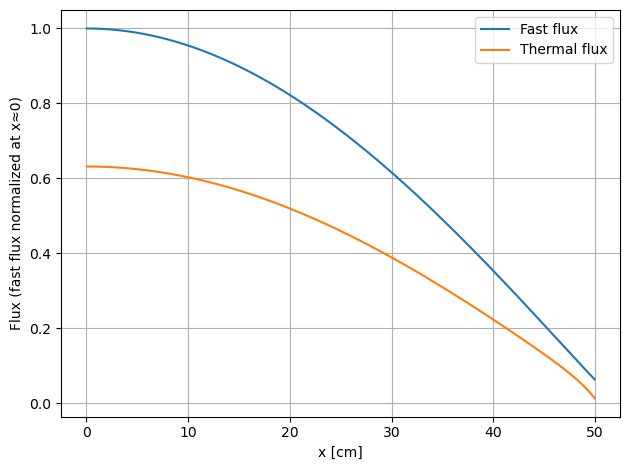

In [3]:
#Q5
import matplotlib.pyplot as plt
#We plot the normalized fast flux and scaled to the same factor thermal flux.
plt.figure()
plt.plot(x, phi_fast_norm,  label="Fast flux")
plt.plot(x, phi_thermal_norm, label="Thermal flux")
plt.xlabel("x [cm]")
plt.ylabel("Flux (fast flux normalized at x≈0)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


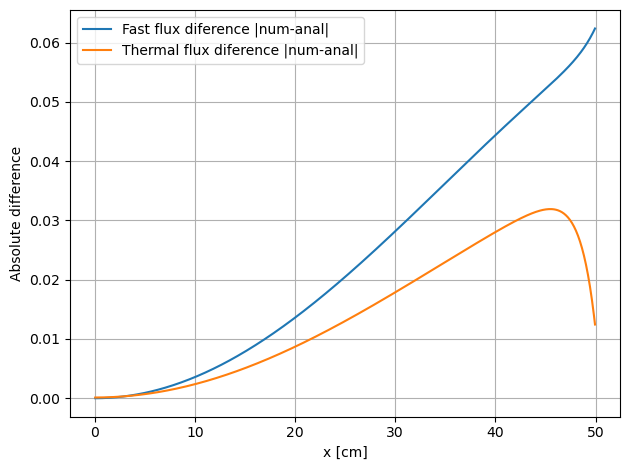

Analytical k_eff (bare core) = 1.08440e+00


In [4]:
#Q6

# Analytical bare-core solution (assuming same spatial shape for both groups):
#  Expanding and applying the BC we find these two equations:
#   phi1(x) = Φ1cos( B * x ), the constant Φ1 multiplying disapears because we are normalizing the fast flux at x=0
#   phi2(x) = Φ2 * cos( B * x )


B = np.pi / (2.0 * a_core)              # fundamental buckling B = π/(2a)
ratio = S12 / (Sa2 + D2 * B**2)         # Φ2 / Φ1 = Σ12 / (Σa2 + D2 B^2)
c1=1                                    #Φ1=1 if we normalize the flux at x=0

# analytical fluxes (before normalization)
phi_fast_anal  = c1*np.cos(B * x)
phi_therm_anal = ratio * np.cos(B * x)

#To be more exact we have to normalize another time the flux but in x=0,05 that is the point exactly
#where the first numerical flux value is computed
phi_fast_anal  /= phi_fast_anal[0]
phi_therm_anal /= phi_fast_anal[0]


# --- Absolute differences numerical vs analytical ---
diff_fast    = np.abs(phi_fast_norm    - phi_fast_anal)
diff_thermal = np.abs(phi_thermal_norm - phi_therm_anal)

# --- Plot ---
plt.figure()
plt.plot(x, diff_fast,    label="Fast flux diference |num-anal|")
plt.plot(x, diff_thermal, label="Thermal flux diference |num-anal|")
plt.xlabel("x [cm]")
plt.ylabel("Absolute difference")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Analytical k_eff for bare core  ---

Sr1 = Sa1 + S12                      # removal XS in fast group

k1 = nusf1 / (D1 * B**2 + Sr1)
k2 = (S12 / (D1 * B**2 + Sr1)) * (nusf2 / (Sa2 + D2 * B**2))

k_eff_anal = k1 + k2

print(f"Analytical k_eff (bare core) = {k_eff_anal:.5e}")


=== Reflected 2-group reactor ===
k_eff (fundamental mode)  = 1.09198e+00
Fast current  J1 at core/reflector interface  ≈ 3.95033e-02  [1/cm^2 s]
Thermal current J2 at core/reflector interface ≈ -5.86376e-03  [1/cm^2 s]


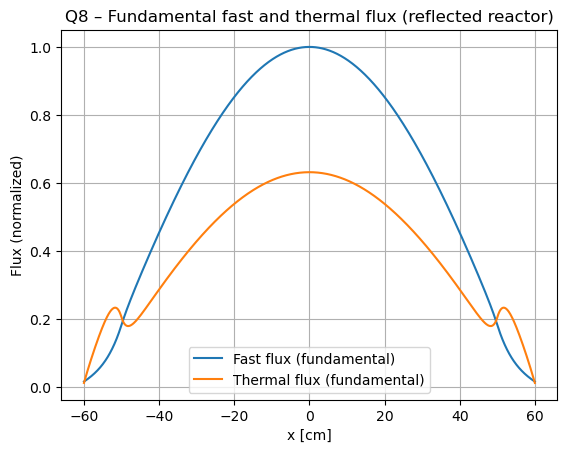

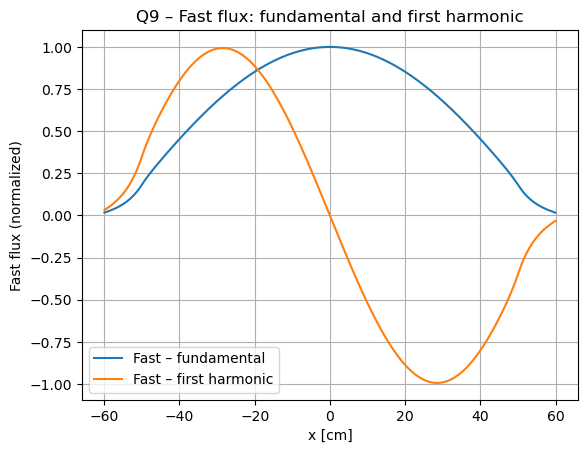

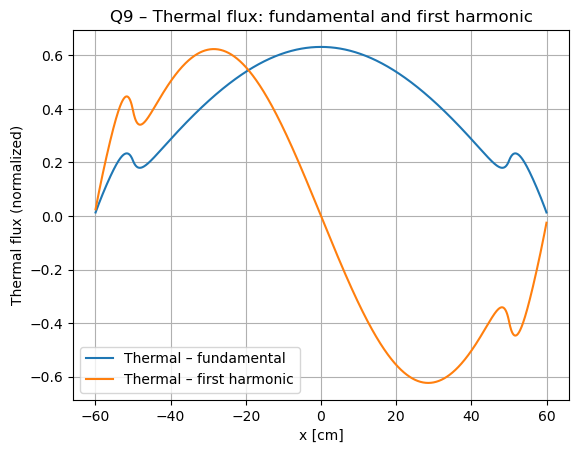

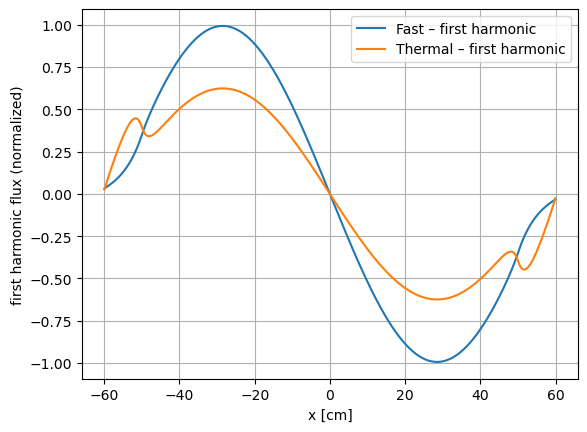

In [5]:

# ============================================================
# Q7–9 : Reflected 2-group reactor (core + reflectors)
# ============================================================

# ----------------------
# Geometry
# ----------------------
a_core = 50.0          # cm  (half thickness of the core, core thickness = 2a = 100 cm)
b_refl = 10.0          # cm  (reflector thickness on each side)
dx     = 0.1           # cm  (mesh size)

N_core = int(2.0 * a_core / dx)   # number of core cells  (100 / 0.1 = 1000)
N_refl = int(b_refl / dx)        # number of reflector cells on each side (10 / 0.1 = 100)
N      = N_core + 2 * N_refl     # total number of spatial cells (core + 2 reflectors)

# ----------------------
# Macroscopic XS
# Group 1 = fast, Group 2 = thermal
# ----------------------

# Diffusion coefficients (same in core and reflector)
D1, D2 = 1.130, 0.160   # cm

# --- CORE ---

Sa1_core, Sa2_core = 0.002, 0.060       # Σ_a,1 , Σ_a,2 [1/cm]
nusf1_core, nusf2_core = 0.001, 0.069   # νΣ_f,1 , νΣ_f,2 [1/cm]
S12_core = 0.038                        # Σ_1->2 [1/cm]

# --- REFLECTOR ---

Sa1_refl, Sa2_refl = 0.000, 0.012       # Σ_a,1 , Σ_a,2 [1/cm]
nusf1_refl, nusf2_refl = 0.0, 0.0       # no fission in the reflector
S12_refl = 0.040                        # Σ_1->2 [1/cm]

S21 = 0.0                               # Σ_2->1 = 0 everywhere

chi1, chi2 = 1.0, 0.0                   # all fission neutrons are born fast

# ----------------------
# Build space-dependent XS arrays (size N)
# ----------------------

Sa1   = np.zeros(N)
Sa2   = np.zeros(N)
nusf1 = np.zeros(N)
nusf2 = np.zeros(N)
S12   = np.zeros(N)

#Now we introduce this values of each cell in the arrays
#Note that the cell 0 is on the  final of the LHS of the reactor, not in the center of the reactor

# Left reflector: cells 0 .. N_refl-1
Sa1[0:N_refl]   = Sa1_refl
Sa2[0:N_refl]   = Sa2_refl
nusf1[0:N_refl] = nusf1_refl
nusf2[0:N_refl] = nusf2_refl
S12[0:N_refl]   = S12_refl

# Core: cells N_refl .. N_refl+N_core-1
i_core_start = N_refl           #note that this index are exclusive, so they are the cell just after
i_core_end   = N_refl + N_core  #the core starts and ends

Sa1[i_core_start:i_core_end]   = Sa1_core
Sa2[i_core_start:i_core_end]   = Sa2_core
nusf1[i_core_start:i_core_end] = nusf1_core
nusf2[i_core_start:i_core_end] = nusf2_core
S12[i_core_start:i_core_end]   = S12_core

# Right reflector: cells i_core_end .. N-1
Sa1[i_core_end:]   = Sa1_refl
Sa2[i_core_end:]   = Sa2_refl
nusf1[i_core_end:] = nusf1_refl
nusf2[i_core_end:] = nusf2_refl
S12[i_core_end:]   = S12_refl

# Removal cross sections Σ_r,g(x)
Sr1 = Sa1 + S12      # Σ_r,1 = Σ_a,1 + Σ_1->2
Sr2 = Sa2 + S21      # Σ_r,2 = Σ_a,2 (since Σ_2->1 = 0)

# Total number of rows in the matrix 
Ntot = 2 * N

# ============================================================
# 1) Build matrices A and F for A φ = (1/k) F φ
# ============================================================

A = np.zeros((Ntot, Ntot))
F = np.zeros((Ntot, Ntot))

#We define a function that by puting the group and the cell we want, returns the row
#in the matrix were are the coeficients of this group in this especific cell
def idx(g, i):
    return g * N + i

# ---- #We introduce the coeficients of the discretized difussion equations into the matrix A ----
for g in (0, 1):
    Dg  = D1 if g == 0 else D2
    Srg = Sr1 if g == 0 else Sr2

    # Interior cells: i = 1 .. N-2
    for i in range(1, N-1):
        row = idx(g, i)
        A[row, idx(g, i-1)] += -Dg / dx**2
        A[row, idx(g, i  )] +=  2.0 * Dg / dx**2 + Srg[i]
        A[row, idx(g, i+1)] += -Dg / dx**2

    # Left boundary (vacuum) at x = -(a + b)
    i = 0
    row = idx(g, i)
    A[row, idx(g, 0)] += 1.0 + 2.0 * Dg / dx
    A[row, idx(g, 1)] += -2.0 * Dg / dx

    # Right boundary (vacuum) at x = +(a + b)
    i = N - 1
    row = idx(g, i)
    A[row, idx(g, N-2)] += -2.0 * Dg / dx
    A[row, idx(g, N-1)] += 1.0 + 2.0 * Dg / dx

# ---- Thermal equation gets a term -Σ_1->2 * φ1_i on the LHS. We explained before why ----
for i in range(N):
    row_thermal = idx(1, i)   
    col_fast    = idx(0, i)  
    A[row_thermal, col_fast] += -S12[i]

# ---- Fission matrix F (only fission source) ----
for i in range(N):
    row_fast = idx(0, i)
    F[row_fast, idx(0, i)] += chi1 * nusf1[i]
    F[row_fast, idx(1, i)] += chi1 * nusf2[i]
    # Thermal rows (g=1) have no direct fission source (chi2 = 0)

# ============================================================
# 2) Solve eigenvalue problem A φ = (1/k) F φ
#    -> (A^{-1} F) φ = k φ
# ============================================================

#We use another time the functions explained in the Q4 for getting the matrix M (M = A^{-1}) 
#without computing the inverse of A and the possible k's(eigvalue) and flux's(eigvector) of the problem
M = np.linalg.solve(A, F)
eigvals, eigvecs = np.linalg.eig(M)



k_real = eigvals.real
idx_sorted = np.argsort(k_real)     #we order index associated to the eigenvalues by ascending order (of their eigenvalues asociated)

# We take the two index of the largest real eigenvalues: fundamental and first harmonic
idx_fund = idx_sorted[-1]          # largest k
idx_harm = idx_sorted[-2]          # second largest k
# We find the two largest real eigenvalues
k_fund = k_real[idx_fund]
k_harm = k_real[idx_harm]

#We compute the eigenvector (flux) associated to these eigenvalues
phi_fund_full = eigvecs[:, idx_fund].real   # fundamental eigenvector
phi_harm_full = eigvecs[:, idx_harm].real   # first harmonic

# Split fundamental flux into fast and thermal parts
phi_fund_fast    = phi_fund_full[0:N]
phi_fund_thermal = phi_fund_full[N:2*N]

# Same with the first harmonic
phi_harm_fast    = phi_harm_full[0:N]
phi_harm_thermal = phi_harm_full[N:2*N]

# ============================================================
# 3) Normalization and currents
# ============================================================

# Index of a cell near the core center (full core, no symmetry)
i_center = i_core_start + N_core // 2   # inside the core

# Global normalization factor:
# fast fundamental flux at the core center is set to 1
scale = 1.0 / phi_fund_fast[i_center]

#now we apply this normalization factor to all the fluxes
phi_fund_fast    *= scale
phi_fund_thermal *= scale
phi_harm_fast    *= scale
phi_harm_thermal *= scale

# Net currents for the fundamental mode at the core/reflector interface (right side)
i_core_right = i_core_end - 1      # last core cell on the right
i_refl_right = i_core_end          # first reflector cell on the right

#we apply fick's law to compute J and finite derivative method to compute the derivative term
J_fast_interface    = -D1 * (phi_fund_fast[i_refl_right]    - phi_fund_fast[i_core_right])    / dx
J_thermal_interface = -D2 * (phi_fund_thermal[i_refl_right] - phi_fund_thermal[i_core_right]) / dx

# We define the spatial coordinates of cell centers with x=0 at the center of the reactor
#(first cell at x=-60) ,(useful for plotting later).
x_left = -(a_core + b_refl)                      # physical coordinate at left external boundary
x = x_left + (np.arange(N) + 0.5) * dx          # cell-center positions

# ============================================================
# 4) Print main numerical results for Question 7
# ============================================================

print("\n=== Reflected 2-group reactor ===")
print(f"k_eff (fundamental mode)  = {k_fund:.5e}")
print(f"Fast current  J1 at core/reflector interface  ≈ {J_fast_interface:.5e}  [1/cm^2 s]")
print(f"Thermal current J2 at core/reflector interface ≈ {J_thermal_interface:.5e}  [1/cm^2 s]")

# ==========================
# Plot for Question 8
# Fast and thermal flux (fundamental mode, full reactor)
# ==========================
plt.figure()
plt.plot(x, phi_fund_fast,    label="Fast flux (fundamental)")
plt.plot(x, phi_fund_thermal, label="Thermal flux (fundamental)")
plt.xlabel("x [cm]")
plt.ylabel("Flux (normalized)")
plt.legend()
plt.grid(True)
plt.title("Q8 – Fundamental fast and thermal flux (reflected reactor)")
plt.show()

# ==========================
# Plot for Question 9
# Eigenvectors of fundamental and first harmonic
# ==========================

# Fast flux: fundamental vs first harmonic
plt.figure()
plt.plot(x, phi_fund_fast, label="Fast – fundamental")
plt.plot(x, phi_harm_fast, label="Fast – first harmonic")
plt.xlabel("x [cm]")
plt.ylabel("Fast flux (normalized)")
plt.legend()
plt.grid(True)
plt.title("Q9 – Fast flux: fundamental and first harmonic")
plt.show()

# Thermal flux: fundamental vs first harmonic
plt.figure()
plt.plot(x, phi_fund_thermal, label="Thermal – fundamental")
plt.plot(x, phi_harm_thermal, label="Thermal – first harmonic")
plt.xlabel("x [cm]")
plt.ylabel("Thermal flux (normalized)")
plt.legend()
plt.grid(True)
plt.title("Q9 – Thermal flux: fundamental and first harmonic")
plt.show()

# first harmonic fast vs thermal
plt.figure()
plt.plot(x, phi_harm_fast, label="Fast – first harmonic")
plt.plot(x, phi_harm_thermal, label="Thermal – first harmonic")
plt.xlabel("x [cm]")
plt.ylabel("first harmonic flux (normalized)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#solution check
print(phi_fast_norm[100])
print(phi_thermal_norm[100])
print(phi_fund_fast[700])
print(phi_fund_thermal[700])

0.9541741790331274
0.60284025563144
0.9620658519990379
0.6080825302775045
